# High-Quality Slide Illustrations

Runs a 128³ LPT simulation with nside=128 and exports three publication-quality
PNG illustrations to `illustrations/`:

1. **Initial Gaussian density field** — 3D orthogonal-face view
2. **Final LPT density field** — 3D orthogonal-face view, log-scaled
3. **Spherical projection** — HEALPix Mollweide map, log-scaled

In [ ]:
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"  # or "cpu" if you want to run on CPU
os.environ["JAX_PLATFORMS"] = "cpu"  # or "cpu" if you want to run on CPU
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt

import jax_fli as jfli

os.makedirs("illustrations", exist_ok=True)

key = jax.random.PRNGKey(0)
mesh_size = (128, 128, 128)
box_size = (1000.0, 1000.0, 1000.0)
nside = 64
shell_width = 100.0
cosmo = jc.Planck18()

print(f"Devices: {jax.devices()}")

# Set font size for plots and activate tex rendering
plt.rcParams.update({"font.size": 18, "text.usetex": True})

Devices: [CpuDevice(id=0)]


In [2]:
nz_shear = jfli.io.get_stage3_nz_shear()
ells = jnp.arange(1, 2000)
cl_shear = jfli.compute_theory_cl(jc.Planck18(), ells, nz_shear)

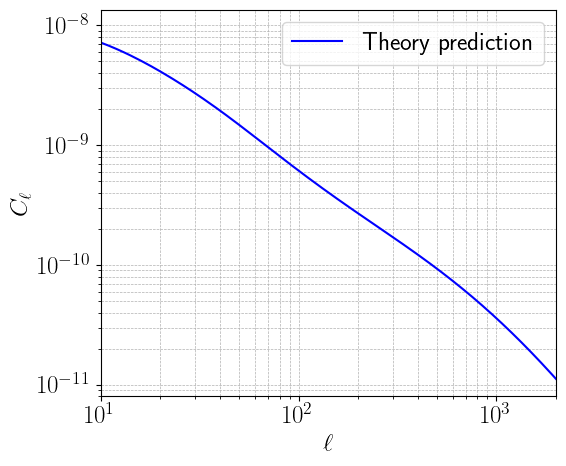

In [3]:
# times coef (2pi )

# set plots font to 18 and activate tex rendering
plt.rcParams.update({"font.size": 18, "text.usetex": True})
plt.figure(figsize=(6, 5))
plt.loglog(cl_shear.wavenumber, cl_shear.spectra[-4], label="Theory prediction", color="blue")
plt.xlabel(r"$\ell$")
plt.xlim(10, 2000)
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.tight_layout()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.savefig("illustrations/theory_pk.svg", dpi=1200, transparent=False)
plt.show()

## 1 — Initial Conditions

Scale factor target: [0.86521292]  (z ≈ [0.15578487])


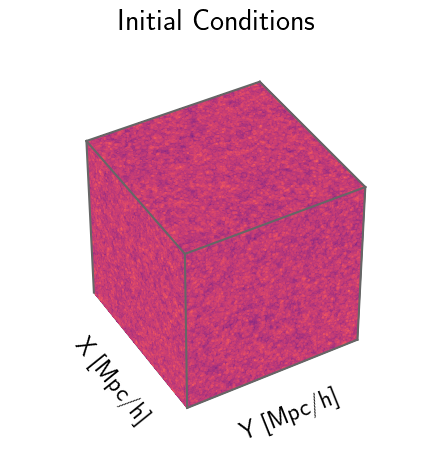

Saved: illustrations/01_initial_conditions.png


In [4]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
)

a_target = jc.background.a_of_chi(cosmo, initial_field.max_comoving_radius - shell_width / 2.0)
print(f"Scale factor target: {a_target}  (z ≈ {1 / a_target - 1})")

fig, _ = initial_field.plot(
    colorbar=False,
    labels=["X [Mpc/h]", "Y [Mpc/h]", ""],
    titles=["Initial Conditions"],
    cmap="magma",
    figsize=(5, 5),
)
fig.savefig("illustrations/01_initial_conditions.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print("Saved: illustrations/01_initial_conditions.png")

## 2 — LPT Displacement

Shell comoving centers [Mpc/h]: [437.5 312.5 187.5  62.5]
Shell scale factors: [0.86856862 0.90346673 0.94039588 0.97957788]
Shell redshifts: [0.15131952 0.10684762 0.06338194 0.02084788]


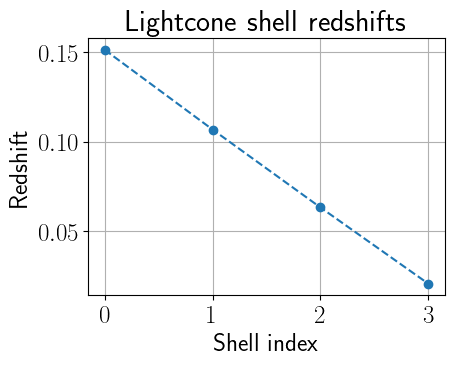

In [5]:
r_center, a_center = jfli.compute_lightcone_shells(cosmo, initial_field, 4)
z_center = jc.utils.a2z(a_center)

print(f"Shell comoving centers [Mpc/h]: {r_center}")
print(f"Shell scale factors: {a_center}")
print(f"Shell redshifts: {z_center}")

fig = plt.figure(figsize=(5, 4))
plt.plot(jnp.arange(4), z_center, linestyle="--", marker="o")
plt.xlabel("Shell index")
plt.ylabel("Redshift")
plt.title("Lightcone shell redshifts")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
dx, p = jfli.lpt(cosmo, initial_field, ts=a_center, order=1)

print(f"Scale factor: {a_center}  (z ≈ {1 / a_center - 1})")
print(f"Particle array shape: {dx.array.shape}")

Scale factor: [0.86856862 0.90346673 0.94039588 0.97957788]  (z ≈ [0.15131952 0.10684762 0.06338194 0.02084788])
Particle array shape: (256, 256, 256, 3)


## 3 — Final 3D Density (log-scaled)

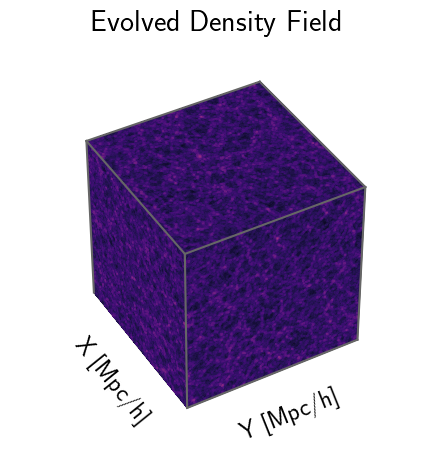

Saved: illustrations/02_final_density.png


In [7]:
density_3d = dx.paint()

fig, _ = density_3d.apply_fn(jnp.log1p).plot(
    colorbar=False,
    labels=["X [Mpc/h]", "Y [Mpc/h]", ""],
    titles=["Evolved Density Field"],
    cmap="magma",
    figsize=(5, 5),
    project_slices=32,
)
fig.savefig("illustrations/02_final_density.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print("Saved: illustrations/02_final_density.png")

## 4 — Spherical (HEALPix / Mollweide) Projection

/home/wassim/micromamba/envs/ffi11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


HEALPix map shape: (4, 196608), nside=128


<Figure size 500x250 with 0 Axes>

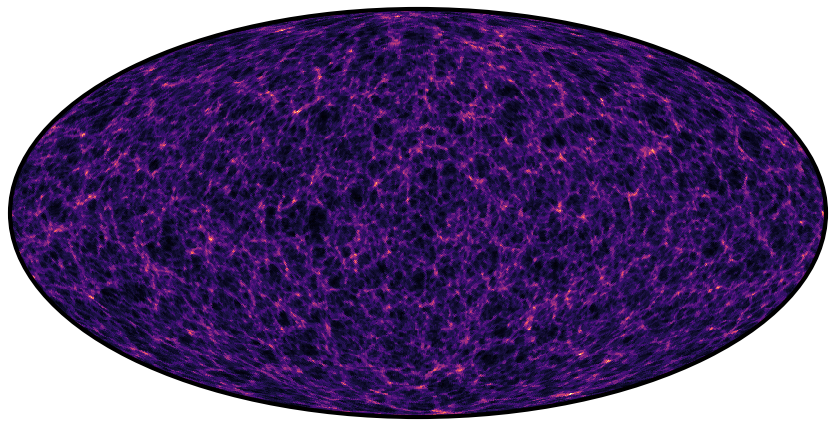

<Figure size 500x250 with 0 Axes>

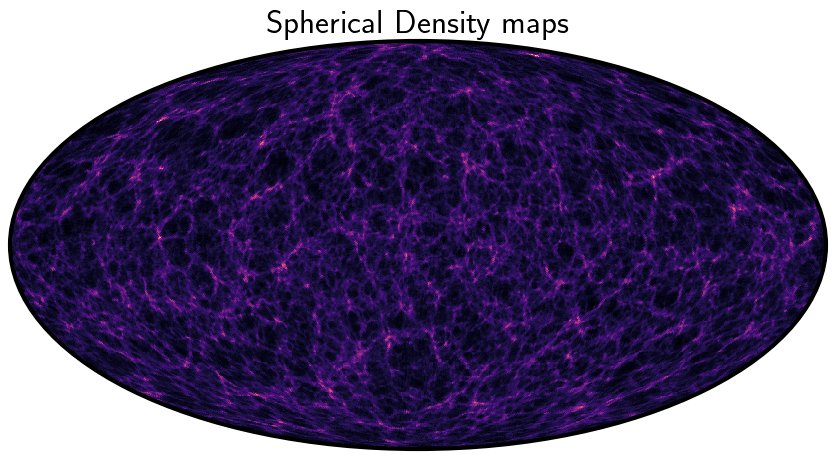

Saved: illustrations/04_spherical_projection.png


In [ ]:
import healpy as hp

r_center = jc.background.radial_comoving_distance(cosmo, a_center)
z_sources = jc.utils.a2z(a_center)
shell_width = jnp.broadcast_to(shell_width, r_center.shape)

spherical_map = dx.to(jfli.units.GRID_ABSOLUTE).paint_spherical(
    center=r_center,
    density_plane_width=shell_width,
    scheme="rbf_neighbor",
)

spherical_map = spherical_map.replace(
    z_sources=z_sources, scale_factors=a_center, comoving_centers=r_center, density_width=shell_width
)

print(f"HEALPix map shape: {spherical_map.array.shape}, nside={spherical_map.nside}")

spherical_map_log = spherical_map.apply_fn(jnp.log1p)

# 1. Plot using projview with all the extra visual elements turned off
fig = plt.figure(figsize=(5, 2.5))
hp.projview(
    spherical_map_log[0].array,
    fig=fig,
    projection_type="mollweide",
    cmap="magma",
    cbar=False,  # Removes the color bar
    graticule=False,  # Removes the internal grid lines and angle labels
    title="",  # Ensures no title is drawn
)

# 2. Grab the current axis to modify the border
ax = plt.gca()

# 3. Target the map's outline (the "spine") and make it thick and black
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Increase this number to make it even thicker
    spine.set_color("black")  # Forces the border color

plt.savefig("illustrations/03_spherical_projection_LR.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()
fontsize: dict

font_size = 24
font_size_dict = {
    "xlabel": font_size,
    "ylabel": font_size,
    "title": font_size,
    "xtick_label": font_size,
    "ytick_label": font_size,
    "cbar_label": font_size,
    "cbar_tick_label": font_size,
}
# 1. Plot using projview with all the extra visual elements turned off
fig = plt.figure(figsize=(5, 2.5))
hp.projview(
    spherical_map_log[1].array,
    fig=fig,
    projection_type="mollweide",
    cmap="magma",
    cbar=False,  # Removes the color bar
    graticule=False,  # Removes the internal grid lines and angle labels
    title="Spherical Density maps",  # Ensures no title is drawn
    fontsize=font_size_dict,
)

# 2. Grab the current axis to modify the border
ax = plt.gca()

# 3. Target the map's outline (the "spine") and make it thick and black
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Increase this number to make it even thicker
    spine.set_color("black")  # Forces the border color

plt.savefig("illustrations/04_spherical_projection_LR.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

print("Saved: illustrations/04_spherical_projection.png")

<Figure size 600x300 with 0 Axes>

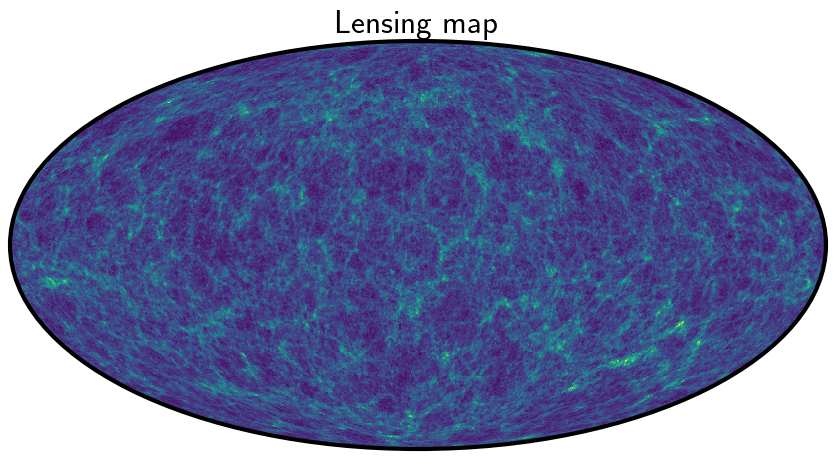

Saved: illustrations/05_lensing_map.png


In [9]:
kappa_maps = jfli.born(cosmo, spherical_map, nz_shear=jnp.array([0.1, 0.15]))
kappa_maps_log = kappa_maps.apply_fn(jnp.log1p)

figure = plt.figure(figsize=(6, 3))
hp.projview(
    kappa_maps_log[1].array,
    fig=figure,
    projection_type="mollweide",
    cmap="viridis",
    cbar=False,  # Removes the color bar
    graticule=False,  # Removes the internal grid lines and angle labels
    title="Lensing map",  # Ensures no title is drawn
    fontsize=font_size_dict,
)

# 2. Grab the current axis to modify the border
ax = plt.gca()

# 3. Target the map's outline (the "spine") and make it thick and black
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Increase this number to make it even thicker
    spine.set_color("black")  # Forces the border color

plt.savefig("illustrations/05_lensing_map.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

print("Saved: illustrations/05_lensing_map.png")